✅ Total images found: 670


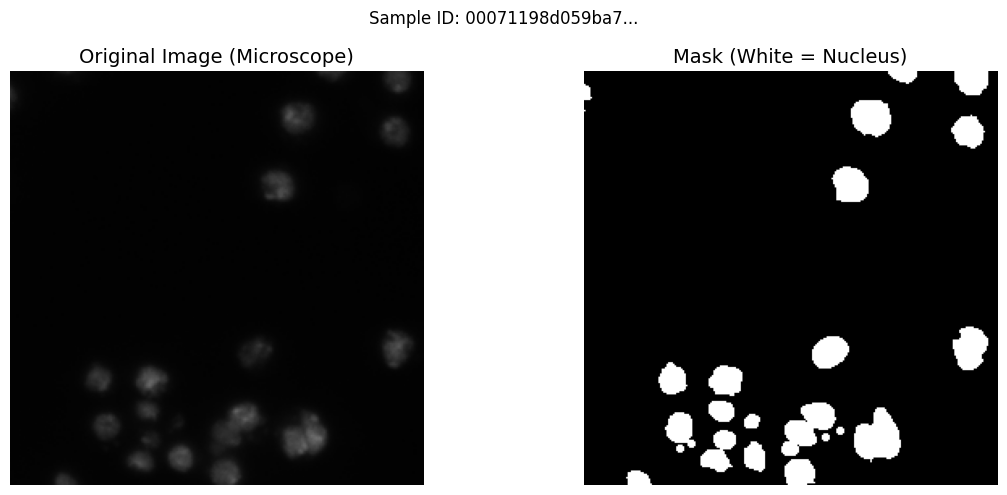

In [ ]:
#Stage 01- Sahinul

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image

# ✅ Point this to where you extracted the Kaggle dataset
TRAIN_PATH = '../images/stage1_train/'

# Get all image folder IDs
image_ids = os.listdir(TRAIN_PATH)
print(f"✅ Total images found: {len(image_ids)}")

# Pick one image to look at
sample_id = image_ids[0]

# Load the image
img_path = os.path.join(TRAIN_PATH, sample_id, 'images', os.listdir(
    os.path.join(TRAIN_PATH, sample_id, 'images'))[0])
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load its mask (the "answer" — where nuclei are)
mask_folder = os.path.join(TRAIN_PATH, sample_id, 'masks')
masks = []
for mask_file in os.listdir(mask_folder):
    mask = cv2.imread(os.path.join(mask_folder, mask_file), 0)
    masks.append(mask)

# Combine all individual masks into one
combined_mask = np.zeros_like(masks[0])
for m in masks:
    combined_mask = np.maximum(combined_mask, m)

# Show the image and its mask side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title('Original Image (Microscope)', fontsize=14)
axes[0].axis('off')

axes[1].imshow(combined_mask, cmap='gray')
axes[1].set_title('Mask (White = Nucleus)', fontsize=14)
axes[1].axis('off')

plt.suptitle(f'Sample ID: {sample_id[:15]}...', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#Stage 02-Sahinul

from tqdm import tqdm  # shows a loading bar

# Settings
IMG_HEIGHT = 128
IMG_WIDTH  = 128
IMG_CHANNELS = 3

# We'll use only first 10 images (as per your project requirement)
NUM_IMAGES = 10
image_ids_subset = image_ids[:NUM_IMAGES]

# Empty arrays to store data
X = np.zeros((NUM_IMAGES, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)
Y = np.zeros((NUM_IMAGES, IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.bool_)

print("📦 Loading and resizing images...")

for i, img_id in enumerate(tqdm(image_ids_subset)):

    # --- Load Image ---
    img_folder = os.path.join(TRAIN_PATH, img_id, 'images')
    img_file   = os.listdir(img_folder)[0]
    img        = cv2.imread(os.path.join(img_folder, img_file))
    img        = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img        = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    X[i]       = img

    # --- Load + Combine Masks ---
    mask_folder = os.path.join(TRAIN_PATH, img_id, 'masks')
    combined    = np.zeros((IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.bool_)

    for mask_file in os.listdir(mask_folder):
        mask_path = os.path.join(mask_folder, mask_file)
        mask      = cv2.imread(mask_path, 0)
        mask      = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
        mask      = np.expand_dims(mask, axis=-1)
        combined  = np.maximum(combined, mask)

    Y[i] = combined

print(f"\n✅ Done!")
print(f"   X shape (images): {X.shape}")   # (10, 128, 128, 3)
print(f"   Y shape (masks):  {Y.shape}")    # (10, 128, 128, 1)

📦 Loading and resizing images...


100%|██████████| 10/10 [00:00<00:00, 23.12it/s]


✅ Done!
   X shape (images): (10, 128, 128, 3)
   Y shape (masks):  (10, 128, 128, 1)


In [ ]:
#Stage 03-Abir

import tensorflow as tf
from tensorflow.keras import layers, Model

def build_unet(input_shape=(128, 128, 3)):
    inputs = layers.Input(input_shape)

    # ---- ENCODER (going down) ----
    c1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    # ---- BOTTLENECK (middle) ----
    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c3)

    # ---- DECODER (going up) ----
    u4 = layers.UpSampling2D((2,2))(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c4)

    u5 = layers.UpSampling2D((2,2))(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(c5)

    # ---- OUTPUT ----
    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c5)

    model = Model(inputs, outputs)
    return model

# Build it!
model = build_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d_8[0][0]  

 Total params: 118,273 (462.00 KB)

 Trainable params: 118,273 (462.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Stage 04-Abir

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Normalize images (pixel values 0-255 → 0.0-1.0)
X_norm = X / 255.0
Y_norm = Y.astype(np.float32)

# Stop training early if it stops improving
early_stop = EarlyStopping(patience=5, verbose=1)

# Save the best version of the model automatically
checkpoint = ModelCheckpoint(
    '../model/best_model.keras',
    save_best_only=True,
    verbose=1
)

print("🚀 Training started...")

history = model.fit(
    X_norm, Y_norm,
    epochs=30,
    batch_size=2,          # small because we only have 10 images
    validation_split=0.2,  # 20% used for testing during training
    callbacks=[early_stop, checkpoint]
)

print("\n✅ Training complete!")

🚀 Training started...
Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8661 - loss: 0.6780
Epoch 1: val_loss improved from None to 0.64556, saving model to ../model/best_model.keras

Epoch 1: finished saving model to ../model/best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 323ms/step - accuracy: 0.8182 - loss: 0.6747 - val_accuracy: 0.8485 - val_loss: 0.6456
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8504 - loss: 0.5864
Epoch 2: val_loss improved from 0.64556 to 0.58841, saving model to ../model/best_model.keras

Epoch 2: finished saving model to ../model/best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8186 - loss: 0.6303 - val_accuracy: 0.8485 - val_loss: 0.5884
Epoch 3/30
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8040 - loss: 0.6479
Epoch 3: val_loss improved from 0.58841 to 0.58090, saving model to ../model/best_model.keras

Epoch 3: finished saving model to ../model/best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/ste

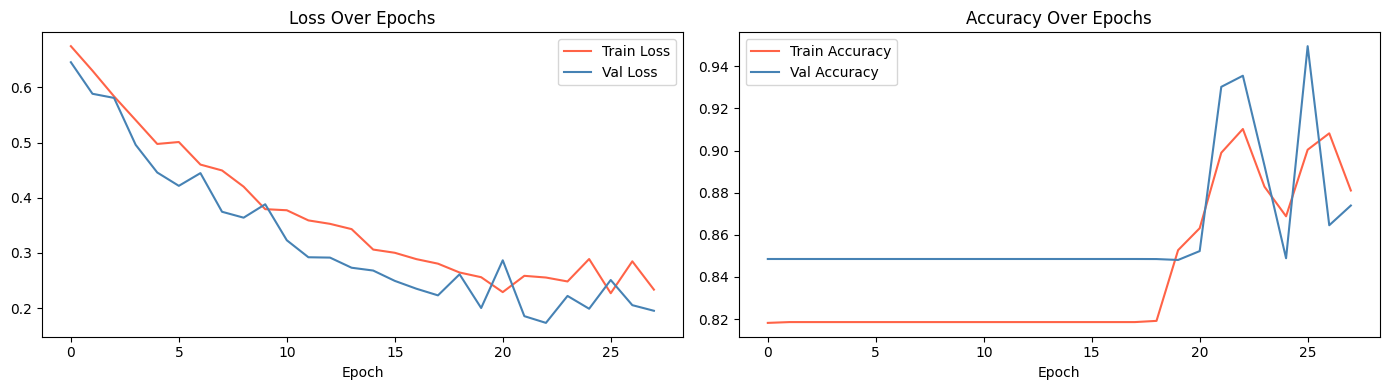


🔍 Comparing predictions vs real masks:



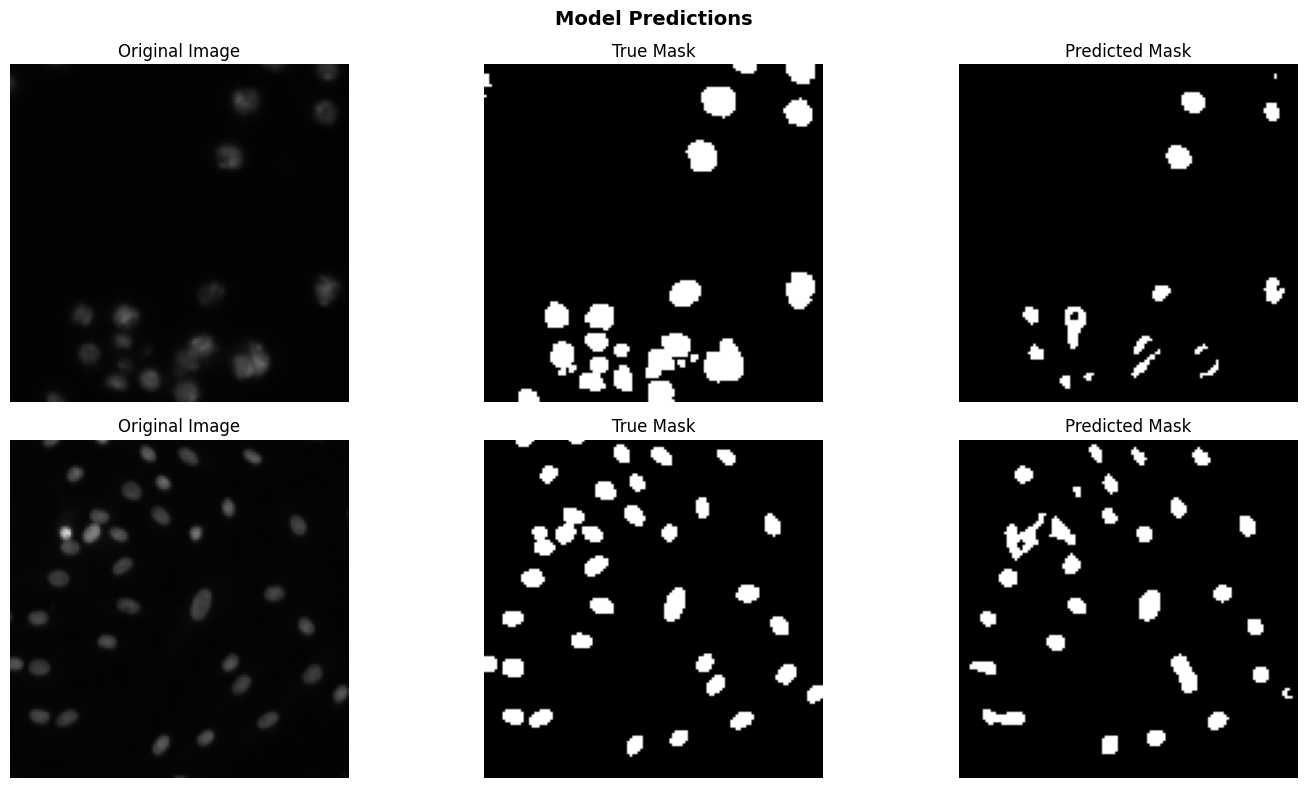

In [ ]:
#Stage 05-Abir

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss', color='tomato')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='steelblue')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='tomato')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='steelblue')
axes[1].set_title('Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

# ---- Show Predictions ----
print("\n🔍 Comparing predictions vs real masks:\n")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i in range(2):
    sample_img  = X_norm[i:i+1]
    pred_mask   = model.predict(sample_img, verbose=0)[0]
    pred_binary = (pred_mask > 0.5).astype(np.uint8)  # threshold at 0.5

    axes[i][0].imshow(X[i])
    axes[i][0].set_title('Original Image')
    axes[i][0].axis('off')

    axes[i][1].imshow(Y[i].squeeze(), cmap='gray')
    axes[i][1].set_title('True Mask')
    axes[i][1].axis('off')

    axes[i][2].imshow(pred_binary.squeeze(), cmap='gray')
    axes[i][2].set_title('Predicted Mask')
    axes[i][2].axis('off')

plt.suptitle('Model Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# STAGE 8-alif

# Normalize
X_aug_norm = X_aug / 255.0
Y_aug_norm = Y_aug.astype(np.float32)

print(f"✅ X_aug_norm shape: {X_aug_norm.shape}")
print(f"✅ Y_aug_norm shape: {Y_aug_norm.shape}")

# Build fresh model
model2 = build_unet()
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("✅ Model built!")

# Callbacks
early_stop2 = EarlyStopping(patience=7, verbose=1, restore_best_weights=True)
checkpoint2 = ModelCheckpoint(
    '../model/best_model_v2.keras',
    save_best_only=True,
    verbose=1
)

print("🚀 Training started...")

history2 = model2.fit(
    X_aug_norm, Y_aug_norm,
    epochs=30,
    batch_size=2,
    validation_split=0.2,
    callbacks=[early_stop2, checkpoint2]
)

print("✅ Stage 8 Done!")

# Verify everything created
print("\n--- Checking variables ---")
print(f"X_aug_norm: {X_aug_norm.shape}")
print(f"Y_aug_norm: {Y_aug_norm.shape}")
print(f"model2: {model2}")

✅ X_aug_norm shape: (40, 128, 128, 3)
✅ Y_aug_norm shape: (40, 128, 128, 1)
✅ Model built!
🚀 Training started...
Epoch 1/30
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7737 - loss: 0.6841
Epoch 1: val_loss improved from None to 0.63630, saving model to ../model/best_model_v2.keras

Epoch 1: finished saving model to ../model/best_model_v2.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.8130 - loss: 0.6672 - val_accuracy: 0.8485 - val_loss: 0.6363
Epoch 2/30
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8180 - loss: 0.5783
Epoch 2: val_loss improved from 0.63630 to 0.47208, saving model to ../model/best_model_v2.keras

Epoch 2: finished saving model to ../model/best_model_v2.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8186 - loss: 0.5640 - val_accuracy: 0.8485 - val_loss: 0.4721
Epoch 3/30
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8371 - loss: 0.4642
Epoch 3: val_loss improved from 0.47208 to 0.45197, saving model to ../model/bes

In [ ]:
# STAGE 9-Alif

# Check if variables exist first
missing = []
for var in ['X_aug_norm', 'Y_aug_norm', 'model2']:
    if var not in dir():
        missing.append(var)

# If anything is missing, create it automatically
if missing:
    print(f"⚠️ Missing: {missing} — fixing automatically...\n")

    if 'X_aug_norm' not in dir() or 'Y_aug_norm' not in dir():
        X_aug_norm = X_aug / 255.0
        Y_aug_norm = Y_aug.astype(np.float32)
        print(f"✅ X_aug_norm created: {X_aug_norm.shape}")
        print(f"✅ Y_aug_norm created: {Y_aug_norm.shape}")

    if 'model2' not in dir():
        model2 = build_unet()
        model2.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])
        early_stop2 = EarlyStopping(patience=7, verbose=1, restore_best_weights=True)
        checkpoint2 = ModelCheckpoint(
            '../model/best_model_v2.keras',
            save_best_only=True,
            verbose=1
        )
        print("🚀 Training model — please wait...")
        history2 = model2.fit(
            X_aug_norm, Y_aug_norm,
            epochs=30,
            batch_size=2,
            validation_split=0.2,
            callbacks=[early_stop2, checkpoint2]
        )
        print("✅ Model trained!")
else:
    print("✅ All variables found! Skipping to evaluation...\n")

# ---- IoU Calculation ----
def calculate_iou(y_true, y_pred, threshold=0.5):
    y_pred_binary = (y_pred > threshold).astype(np.float32)
    y_true_binary = y_true.astype(np.float32)

    intersection = np.sum(y_true_binary * y_pred_binary)
    union        = np.sum(y_true_binary) + np.sum(y_pred_binary) - intersection

    if union == 0:
        return 1.0
    return intersection / union

# Test on last 10 images
val_images  = X_aug_norm[-10:]
val_masks   = Y_aug_norm[-10:]
predictions = model2.predict(val_images, verbose=0)

print("\n📊 IoU Results:")
print("-" * 30)

iou_scores = []
for i in range(len(val_images)):
    iou = calculate_iou(val_masks[i], predictions[i])
    iou_scores.append(iou)

    if iou >= 0.7:
        indicator = "🟢 Good"
    elif iou >= 0.5:
        indicator = "🟡 Okay"
    else:
        indicator = "🔴 Poor"

    print(f"  Image {i+1:02d}: IoU = {iou:.4f}  {indicator}")

print("-" * 30)
print(f"\n🎯 Average IoU Score : {np.mean(iou_scores):.4f}")
print(f"📈 Best IoU Score    : {np.max(iou_scores):.4f}")
print(f"📉 Worst IoU Score   : {np.min(iou_scores):.4f}")
print("\n(Score closer to 1.0 = better!)")

✅ All variables found! Skipping to evaluation...


📊 IoU Results:
------------------------------
  Image 01: IoU = 0.0000  🔴 Poor
  Image 02: IoU = 0.7611  🟢 Good
  Image 03: IoU = 0.5362  🟡 Okay
  Image 04: IoU = 0.0138  🔴 Poor
  Image 05: IoU = 0.3377  🔴 Poor
  Image 06: IoU = 0.5531  🟡 Okay
  Image 07: IoU = 0.7743  🟢 Good
  Image 08: IoU = 0.0000  🔴 Poor
  Image 09: IoU = 0.7662  🟢 Good
  Image 10: IoU = 0.7903  🟢 Good
------------------------------

🎯 Average IoU Score : 0.4533
📈 Best IoU Score    : 0.7903
📉 Worst IoU Score   : 0.0000

(Score closer to 1.0 = better!)


In [ ]:
# STAGE 10-Alif

import os
os.makedirs('../model', exist_ok=True)

# Save
model2.save('../model/nuclei_final_model.keras')
print("✅ Model saved!")

# Load back
from tensorflow.keras.models import load_model
loaded_model = load_model('../model/nuclei_final_model.keras')
print("✅ Model loaded successfully!")

# Quick test
test_pred = loaded_model.predict(X_aug_norm[0:1], verbose=0)
print(f"✅ Test prediction shape: {test_pred.shape}")

✅ Model saved!
✅ Model loaded successfully!
✅ Test prediction shape: (1, 128, 128, 1)
